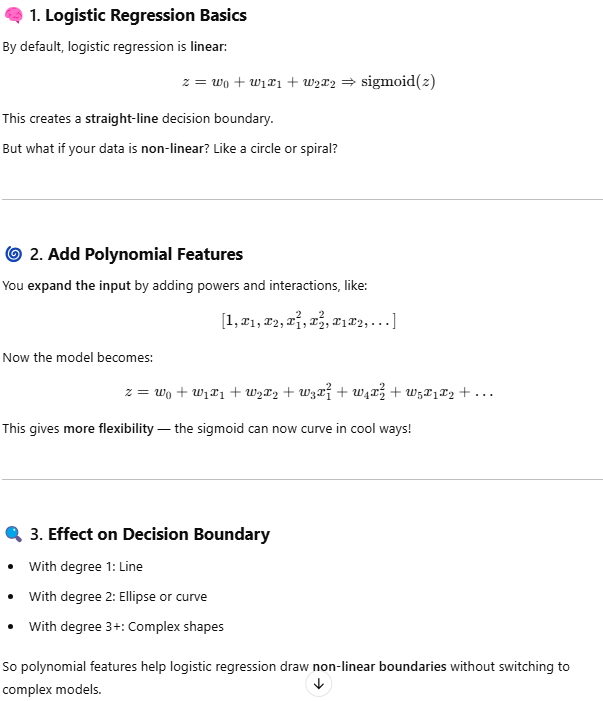

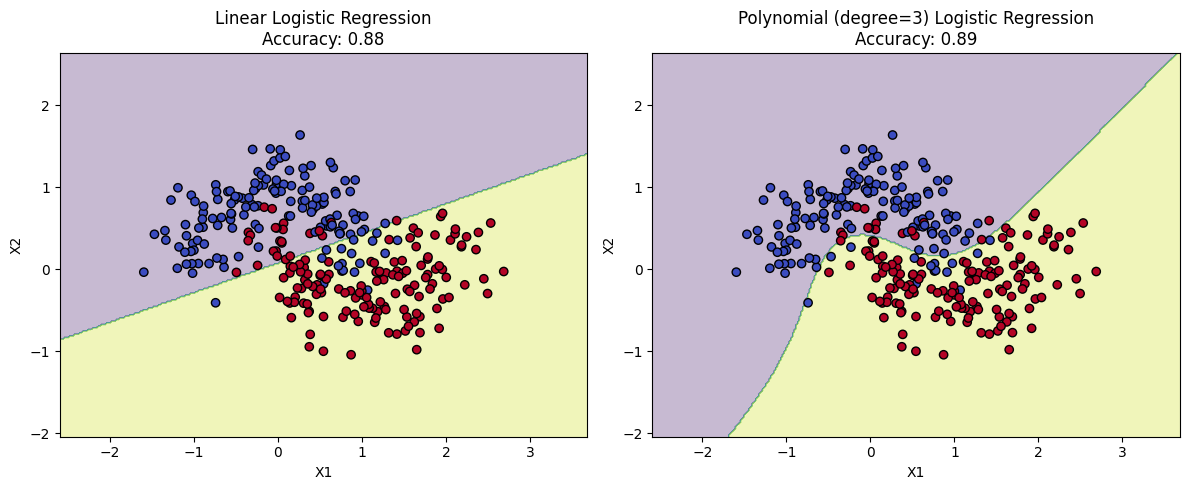

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Create toy non-linear data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Train linear logistic regression
linear_model = LogisticRegression()
linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)
linear_acc = accuracy_score(y_test, linear_preds)

# Step 3: Train logistic regression with polynomial features
poly_model = make_pipeline(PolynomialFeatures(degree=3), LogisticRegression(max_iter=1000))
poly_model.fit(X_train, y_train)
poly_preds = poly_model.predict(X_test)
poly_acc = accuracy_score(y_test, poly_preds)

# Step 4: Plot decision boundaries
def plot_boundary(model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.tight_layout()

# Step 5: Plot both
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_boundary(linear_model, f"Linear Logistic Regression\nAccuracy: {linear_acc:.2f}")

plt.subplot(1, 2, 2)
plot_boundary(poly_model, f"Polynomial (degree=3) Logistic Regression\nAccuracy: {poly_acc:.2f}")

plt.show()


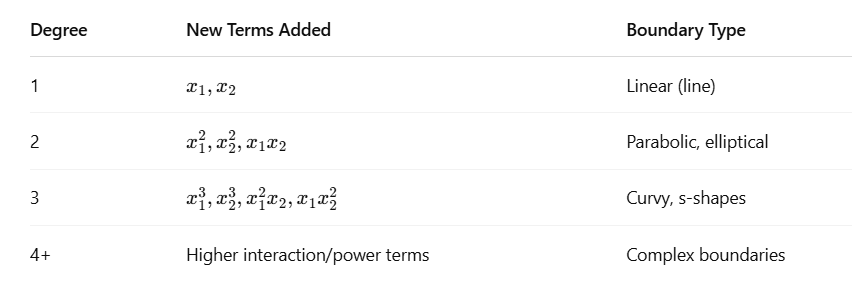